## Import required packages

In [3]:
import os
import sys
import copy
import numpy as np
import networkx as nx
import reg_path_partial_linearization

import dsd
from super_greedy_set_linear import *
import utils
import matplotlib.pyplot as plt 
import matplotlib
%matplotlib inline 
import pandas as pd
from init_graph import init_graph

import matplotlib.patches as mpatches


from tqdm import tqdm


# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

plt.rcParams["figure.dpi"]=100
plt.rcParams['savefig.dpi']=300


## Create regularization path plots

In [ ]:
dataset_name = 'cosponsorBel'

import numpy as np 

if dataset_name == 'polbooks':
    load_path = r'logs\polbooks\polbooks_log.npy'
elif dataset_name == 'cosponsorBel':
    load_path = r'logs/cosponsorBel/cosponsorBel_log.npy'
elif dataset_name == 'cosponsorIt':
    load_path = r'logs/cosponsorIt/cosponsorIt_log.npy'
    
variables_dict_ = np.load(load_path, allow_pickle=True)

lam_vec = variables_dict_.item().get('lam')
super_greedy_pp_R = variables_dict_.item().get('induced')
num_of_nodes = variables_dict_.item().get('num_of_nodes')
density_vec = variables_dict_.item().get('density')
num_of_protected_vec = variables_dict_.item().get('num_of_protected')
protected_portion_in_sub_vec = variables_dict_.item().get('protected_portion_in_sub')
protected_portion_in_prot_vec = variables_dict_.item().get('protected_portion_in_prot')
fairness_vec = variables_dict_.item().get('fairness')
g_vec = variables_dict_.item().get('g')
LSE_values = variables_dict_.item().get('neg_lse_values')
cost_value = variables_dict_.item().get('cost_value')
nonfairddensity = variables_dict_.item().get('nonfairddensity')


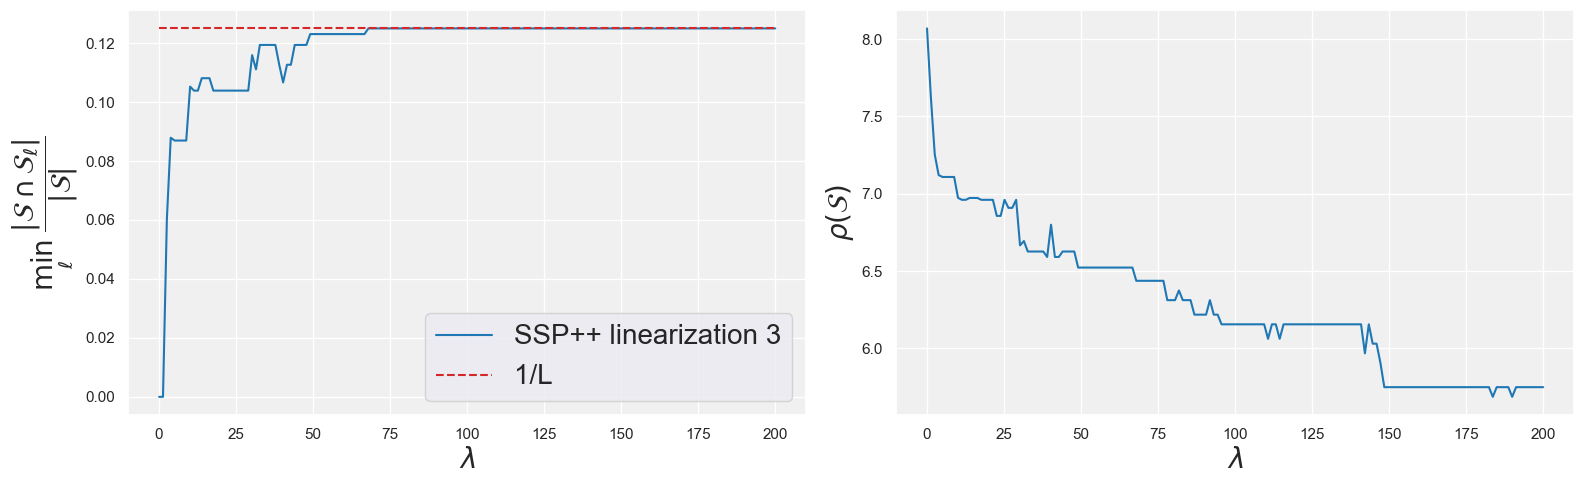

In [13]:
L = 8
Lvec = [1.0/L for _ in range(len(lam_vec))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Minimum represented proportion ──
ax1.set_facecolor('#f0f0f0')
ax1.plot((lam_vec),protected_portion_in_sub_vec, color="tab:blue", label="SSP++ linearization 3")
ax1.plot((lam_vec), Lvec, color="tab:red", linestyle="dashed", label="1/L")
ax1.set_xlabel(r"$\lambda$",fontsize=20)
ax1.set_ylabel(r"$\underset{\ell}{\mathrm{min}} \; \dfrac{|\mathcal{S} \cap \mathcal{S}_{\ell}|}{|\mathcal{S}|}$",fontsize=20)
ax1.legend(fontsize=20)

# ── Right: Density ──
ax2.set_facecolor('#f0f0f0')
ax2.plot((lam_vec), [2*density_vec[i] for i in range(len(density_vec))], color="tab:blue")
ax2.set_xlabel(r"$\lambda$",fontsize=20)
ax2.set_ylabel(r"$\rho(\mathcal{S})$",fontsize=20)

plt.tight_layout()
plt.savefig(f"{dataset_name}/sweep_{dataset_name}.pdf", format='pdf', bbox_inches='tight')
plt.show()

## calculate the $\mu$ sweep

Converged at outer iteration 2
Converged at outer iteration 4
Converged at outer iteration 2
Converged at outer iteration 4
Converged at outer iteration 3
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 4
Converged at outer iteration 4
Converged at outer iteration 6
Converged at outer iteration 5
Converged at outer iteration 4
Converged at outer iteration 4
Converged at outer iteration 9
Converged at outer iteration 7
Converged at outer iteration 8
Converged at outer iteration 5
Converged at outer iteration 5
Converged at outer iteration 6
Converged at outer iteration 5
Converged at outer iteration 5
Converged at outer iteration 7
Converged at outer iteration 8
Converged at outer iteration 5
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 5
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 6
Converge

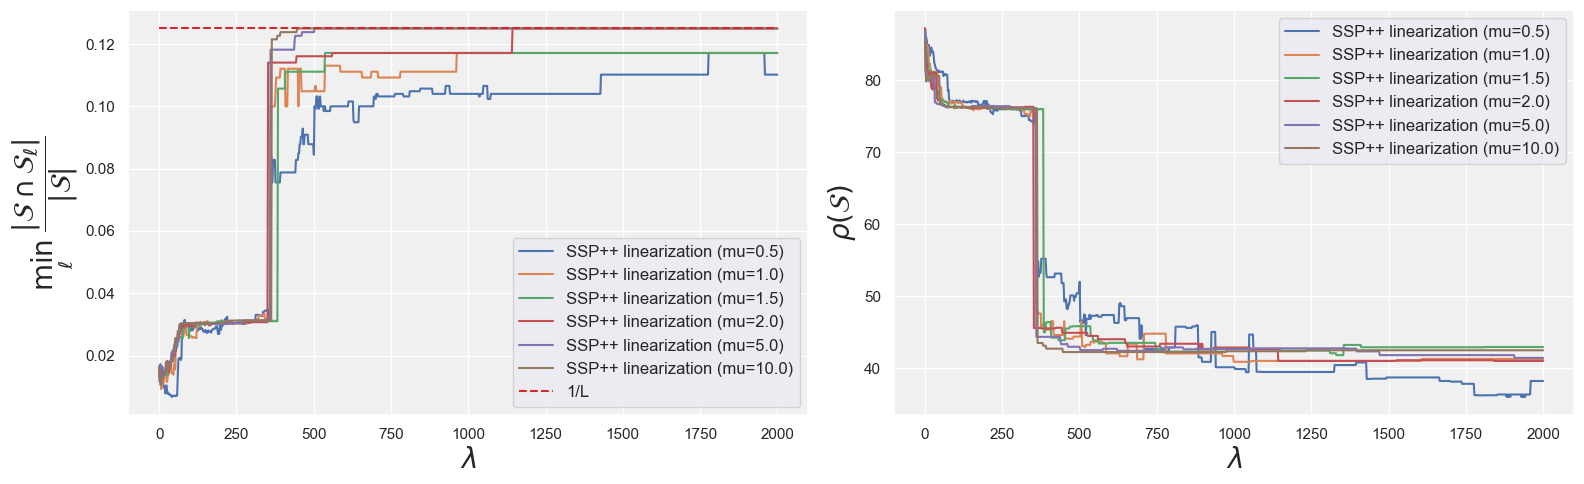

In [ ]:
L = 8
dataset_name = 'cosponsorIt'
lin_method = 1
G,protected_nodes = init_graph(dataset_name)
lam_vec = np.linspace(0.1,2000.0,1000)
L_vec = [1.0/L for _ in range(len(lam_vec))]
muVec = [0.5,1.0,1.5,2.0,5.0,10.0]

densityvec_collection = []
protected_portion_in_sub_vec_collection = []
for mu in muVec:
    density_vec = []
    protected_portion_in_sub_vec = []
    for lam in lam_vec:
        super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, G, protected_nodes_all=protected_nodes, lam=lam, mu=mu, alpha=None, num_passes=5,num_outer=10, lin_method=lin_method)
        density_vec.append(utils.compute_density(super_greedy_pp_R[0], G))
        protected_portion_in_sub_vec.append(np.min([len(set(super_greedy_pp_R[0]).intersection(set(prot_nodes)))/len(super_greedy_pp_R[0]) for prot_nodes in protected_nodes]))
    densityvec_collection.append(density_vec)
    protected_portion_in_sub_vec_collection.append(protected_portion_in_sub_vec)

## Plotting the results for different mu values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
# ── Left: Minimum represented proportion ──
ax1.set_facecolor('#f0f0f0')
for i, mu in enumerate(muVec):
    ax1.plot((lam_vec), protected_portion_in_sub_vec_collection[i], label=f"SSP++ linearization (mu={mu})")
ax1.plot((lam_vec), L_vec, color="tab:red", linestyle="dashed", label="1/L")
ax1.set_xlabel(r"$\lambda$",fontsize=20)
ax1.set_ylabel(r"$\underset{\ell}{\mathrm{min}} \; \dfrac{|\mathcal{S} \cap \mathcal{S}_{\ell}|}{|\mathcal{S}|}$",fontsize=20)
ax1.legend(fontsize=12)
# ── Right: Density ──
ax2.set_facecolor('#f0f0f0')
for i, mu in enumerate(muVec):
    ax2.plot((lam_vec), [2*densityvec_collection[i][j] for j in range(len(densityvec_collection[i]))], label=f"SSP++ linearization (mu={mu})")
ax2.set_xlabel(r"$\lambda$",fontsize=20)
ax2.set_ylabel(r"$\rho(\mathcal{S})$",fontsize=20)
ax2.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"{dataset_name}/sweep_{dataset_name}_mu_sensitivity.pdf", format='pdf', bbox_inches='tight')
plt.show()







## Calculate the $\alpha$ sweep

Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Converged at outer iteration 1
Rejected non-improving step at outer iteration 1; stopping (obj 87.711889 < 87.717039).
Rejected non-improving step at outer iteration 1; stopping (obj 87.753996 < 87.755611).
Rejected non-improving step at outer iteration 2; stopping (obj 87.794829 < 87.796103).
Converged at outer iteration 2
Converged at outer iteration 2
Converged at outer iteration 2
Converged at outer iteration 2
Rejected non-improving step at outer iteration 1; stopping (obj 87.969863 < 87.987006).
Rejected non-improving step at outer iteration 1; stopping (obj 88.002324 < 88.026060).
Rejected non-improving step at ou

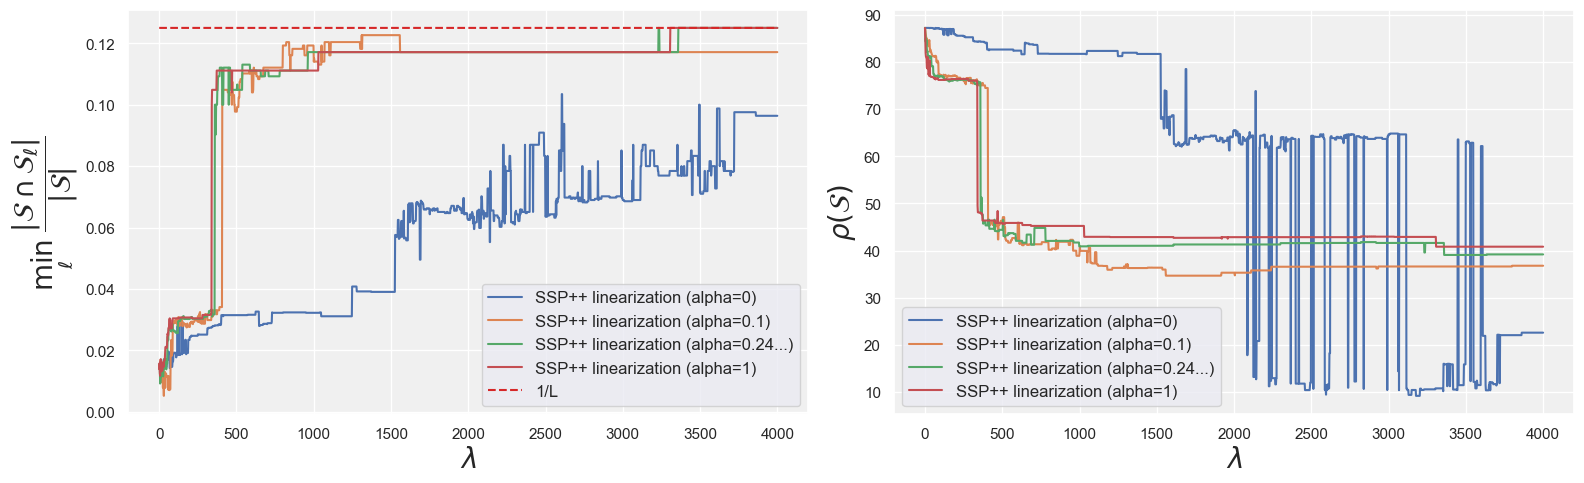

In [ ]:
L = 8
dataset_name = 'cosponsorIt'
G,protected_nodes = init_graph(dataset_name)
lam_vec = np.linspace(0.1,4000.0,2000)
L_vec = [1.0/L for _ in range(len(lam_vec))]
## none is the default value
alpha_Vec = [0,0.1,None,1]

densityvec_collection = []
protected_portion_in_sub_vec_collection = []
for alpha in alpha_Vec:
    density_vec = []
    protected_portion_in_sub_vec = []
    for lam in lam_vec:
        super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, G, protected_nodes_all=protected_nodes, lam=lam, mu=1, alpha=alpha, num_passes=5,num_outer=10)
        density_vec.append(utils.compute_density(super_greedy_pp_R[0], G))
        protected_portion_in_sub_vec.append(np.min([len(set(super_greedy_pp_R[0]).intersection(set(prot_nodes)))/len(super_greedy_pp_R[0]) for prot_nodes in protected_nodes]))
    densityvec_collection.append(density_vec)
    protected_portion_in_sub_vec_collection.append(protected_portion_in_sub_vec)

## Plotting the results for different alpha values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
# ── Left: Minimum represented proportion ──
ax1.set_facecolor('#f0f0f0')
for i, alpha in enumerate(alpha_Vec):
    ax1.plot((lam_vec), protected_portion_in_sub_vec_collection[i], label=f"SSP++ linearization (alpha={alpha if alpha is not None else '0.24...'})")
ax1.plot((lam_vec), L_vec, color="tab:red", linestyle="dashed", label="1/L")
ax1.set_xlabel(r"$\lambda$",fontsize=20)
ax1.set_ylabel(r"$\underset{\ell}{\mathrm{min}} \; \dfrac{|\mathcal{S} \cap \mathcal{S}_{\ell}|}{|\mathcal{S}|}$",fontsize=20)
ax1.legend(fontsize=12)
# ── Right: Density ──
ax2.set_facecolor('#f0f0f0')
for i, alpha in enumerate(alpha_Vec):
    ax2.plot((lam_vec), [2*densityvec_collection[i][j] for j in range(len(densityvec_collection[i]))], label=f"SSP++ linearization (alpha={alpha if alpha is not None else '0.24...'})")
ax2.set_xlabel(r"$\lambda$",fontsize=20)
ax2.set_ylabel(r"$\rho(\mathcal{S})$",fontsize=20)
ax2.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"{dataset_name}/sweep_{dataset_name}_alpha_sensitivity_lin2.pdf", format='pdf', bbox_inches='tight')
plt.show()







Converged at outer iteration 1
Converged at outer iteration 2
Converged at outer iteration 3
Converged at outer iteration 4
Converged at outer iteration 5
Converged at outer iteration 4
Converged at outer iteration 4
Converged at outer iteration 7
Converged at outer iteration 6
Converged at outer iteration 7
Converged at outer iteration 5
Converged at outer iteration 5
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 8
Converged at outer iteration 7
Converged at outer iteration 6
Converged at outer iteration 6
Converged at outer iteration 4
Converged at outer iteration 4
Converged at outer iteration 3
Converged at outer iteration 3
Converged at outer iteration 3
Converged at outer iteration 4
Converged at outer iteration 5
Converged at outer iteration 4
Converged at outer iteration 2
Converged at outer iteration 2
Converged at outer iteration 2
Converged at outer iteration 2
Converged at outer iteration 2
Converged at outer iteration 1
Converge

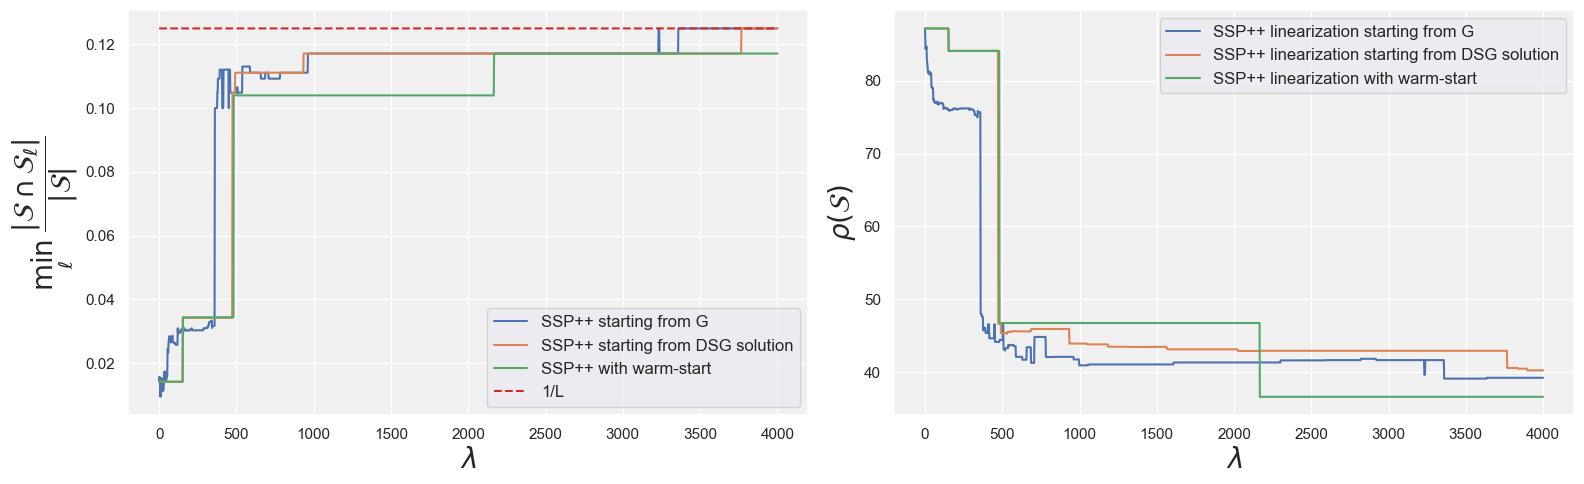

In [ ]:
L = 8
dataset_name = 'cosponsorIt'
lin_method = 1
G,protected_nodes = init_graph(dataset_name)
lam_vec = np.linspace(0,4000.0,2000)
L_vec = [1.0/L for _ in range(len(lam_vec))]

densityvec_collection = []
protected_portion_in_sub_vec_collection = []
density_vec = []
protected_portion_in_sub_vec = []
#start with the entire graph
for lam in lam_vec:
    super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, G, protected_nodes_all=protected_nodes, lam=lam, mu=1, alpha=None, num_passes=5,num_outer=10, lin_method=lin_method)
    density_vec.append(utils.compute_density(super_greedy_pp_R[0], G))
    protected_portion_in_sub_vec.append(np.min([len(set(super_greedy_pp_R[0]).intersection(set(prot_nodes)))/len(super_greedy_pp_R[0]) for prot_nodes in protected_nodes]))
densityvec_collection.append(density_vec)
protected_portion_in_sub_vec_collection.append(protected_portion_in_sub_vec)
#start with the DSG solution of the entire graph
super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, G, protected_nodes_all=protected_nodes, lam=0.1, mu=1, alpha=None, num_passes=5,num_outer=10, lin_method=lin_method)
S0 = super_greedy_pp_R[0]
density_vec = []
protected_portion_in_sub_vec = []
for lam in lam_vec:
    super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, S0, protected_nodes_all=protected_nodes, lam=lam, mu=1, alpha=None, num_passes=5,num_outer=10, lin_method=lin_method)
    density_vec.append(utils.compute_density(super_greedy_pp_R[0], G))
    protected_portion_in_sub_vec.append(np.min([len(set(super_greedy_pp_R[0]).intersection(set(prot_nodes)))/len(super_greedy_pp_R[0]) for prot_nodes in protected_nodes]))
densityvec_collection.append(density_vec)
protected_portion_in_sub_vec_collection.append(protected_portion_in_sub_vec)
#reuse the previous solution as the starting point for the next iteration
density_vec = []
protected_portion_in_sub_vec = []
S0 = G
for lam in lam_vec:
    super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, S0, protected_nodes_all=protected_nodes, lam=lam, mu=1, alpha=None, num_passes=5,num_outer=10, lin_method=lin_method)
    density_vec.append(utils.compute_density(super_greedy_pp_R[0], G))
    protected_portion_in_sub_vec.append(np.min([len(set(super_greedy_pp_R[0]).intersection(set(prot_nodes)))/len(super_greedy_pp_R[0]) for prot_nodes in protected_nodes]))
    S0 = G.subgraph(super_greedy_pp_R[0])
densityvec_collection.append(density_vec)
protected_portion_in_sub_vec_collection.append(protected_portion_in_sub_vec)

## Plotting the results for different alpha values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
# ── Left: Minimum represented proportion ──
ax1.set_facecolor('#f0f0f0')
ax1.plot((lam_vec), protected_portion_in_sub_vec_collection[0], label=f"SSP++ starting from G ")
ax1.plot((lam_vec), protected_portion_in_sub_vec_collection[1], label=f"SSP++ starting from DSG solution")
ax1.plot((lam_vec), protected_portion_in_sub_vec_collection[2], label=f"SSP++ with warm-start")
ax1.plot((lam_vec), L_vec, color="tab:red", linestyle="dashed", label="1/L")
ax1.set_xlabel(r"$\lambda$",fontsize=20)
ax1.set_ylabel(r"$\underset{\ell}{\mathrm{min}} \; \dfrac{|\mathcal{S} \cap \mathcal{S}_{\ell}|}{|\mathcal{S}|}$",fontsize=20)
ax1.legend(fontsize=12)
# ── Right: Density ──
ax2.set_facecolor('#f0f0f0')
ax2.plot((lam_vec), [2*densityvec_collection[0][j] for j in range(len(densityvec_collection[0]))], label=f"SSP++ linearization starting from G ")
ax2.plot((lam_vec), [2*densityvec_collection[1][j] for j in range(len(densityvec_collection[1]))], label=f"SSP++ linearization starting from DSG solution")
ax2.plot((lam_vec), [2*densityvec_collection[2][j] for j in range(len(densityvec_collection[2]))], label=f"SSP++ linearization with warm-start")
ax2.set_xlabel(r"$\lambda$",fontsize=20)
ax2.set_ylabel(r"$\rho(\mathcal{S})$",fontsize=20)
ax2.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"{dataset_name}/sweep_{dataset_name}_initgraph_lin2.pdf", format='pdf', bbox_inches='tight')
plt.show()







## Direct analysis for Polbooks

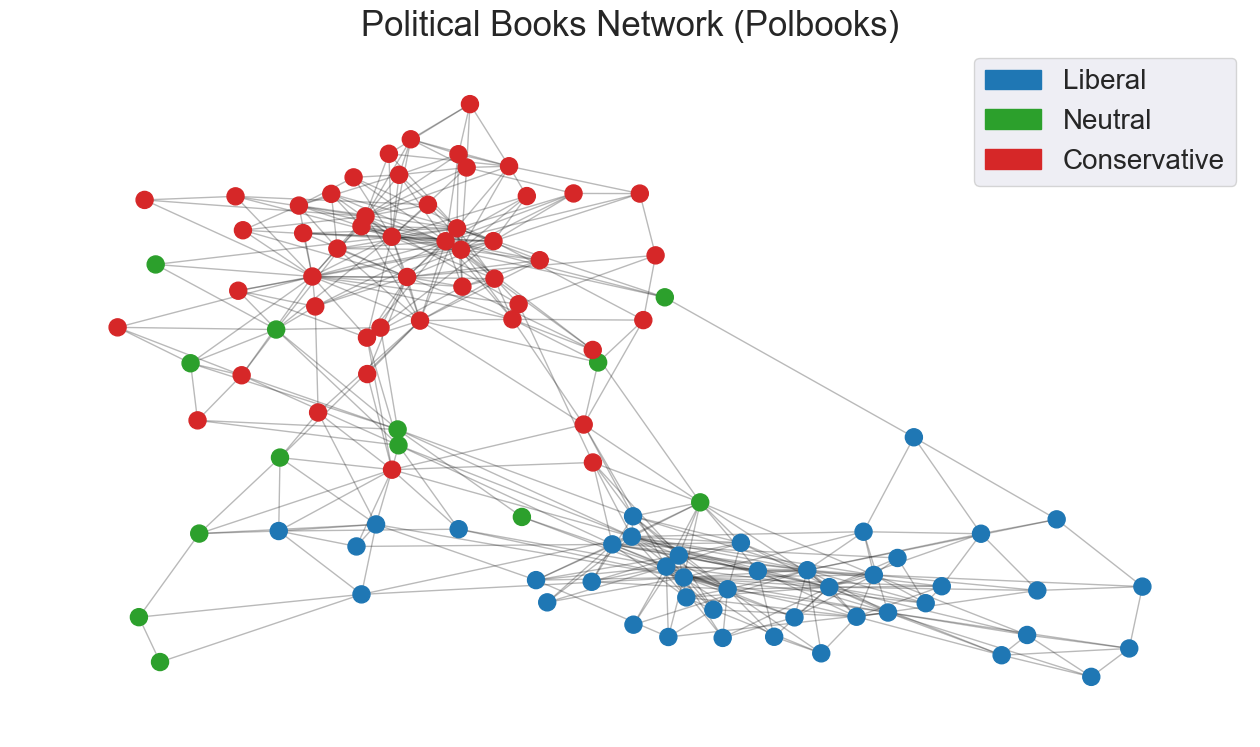

<Figure size 640x480 with 0 Axes>

In [8]:
G = nx.read_gml("datasets/pol_books/polbooks.gml")

_,protected_nodes = init_graph("polbooks")

color_map = {
    'l': 'tab:blue',
    'n': 'tab:green',
    'c': 'tab:red'
}
node_colors = [color_map[G.nodes[n]['value']] for n in G.nodes()]
pos = nx.spring_layout(G, seed=42)

# Plot
plt.figure(figsize=(16, 9))
ax = plt.gca()
ax.set_facecolor("#ffffff")   
plt.title("Political Books Network (Polbooks)",fontsize = 25)
legend_handles = [
   mpatches.Patch(color='tab:blue', label='Liberal'),
   mpatches.Patch(color='tab:green', label='Neutral'),
   mpatches.Patch(color='tab:red', label='Conservative')
]
plt.legend(handles=legend_handles, loc='upper right',fontsize=20)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=150)
nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.show()
dataset_name = "polbooks"
plt.savefig(f"full_graph_{dataset_name}.pdf", format='pdf', bbox_inches='tight')






Converged at outer iteration 1
Converged at outer iteration 1
4.75


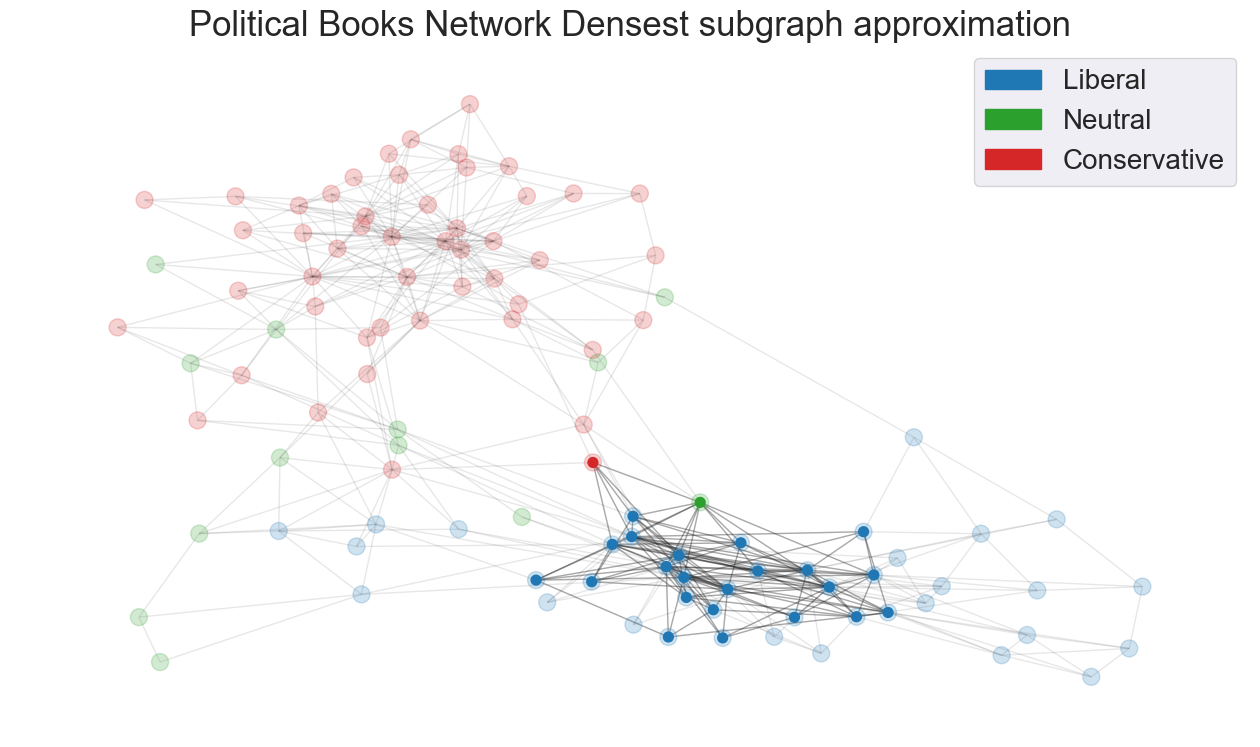

In [ ]:
super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, G, protected_nodes_all=protected_nodes, lam=0, mu=1.0, alpha=None, num_passes=5)
S= G.subgraph(super_greedy_pp_R[0])
super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, S, protected_nodes_all=protected_nodes, lam=0, mu=1.0, alpha=None, num_passes=10)
S= G.subgraph(super_greedy_pp_R[0])

node_colors_G = [color_map[G.nodes[n]['value']] for n in G.nodes()]
node_colors_S = [color_map[S.nodes[n]['value']] for n in S.nodes()]

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(16, 9))
ax = plt.gca()
ax.set_facecolor("#ffffff")   
plt.title("Political Books Network Densest subgraph approximation",fontsize = 25)
legend_handles = [
   mpatches.Patch(color='tab:blue', label='Liberal'),
   mpatches.Patch(color='tab:green', label='Neutral'),
   mpatches.Patch(color='tab:red', label='Conservative')
]
plt.legend(handles=legend_handles, loc='upper right',fontsize=20)

nx.draw_networkx_nodes(G, pos, node_color=node_colors_G, node_size=150,alpha = 0.21)
nx.draw_networkx_edges(G, pos, alpha=0.1)

nx.draw_networkx_nodes(S, pos, node_color=node_colors_S, node_size=50)

nx.draw_networkx_edges(S, pos, alpha=0.3)
print(2*S.number_of_edges()/S.number_of_nodes())
plt.savefig(f"densest_subgraph_{dataset_name}.pdf", format='pdf', bbox_inches='tight')

3.5384615384615383


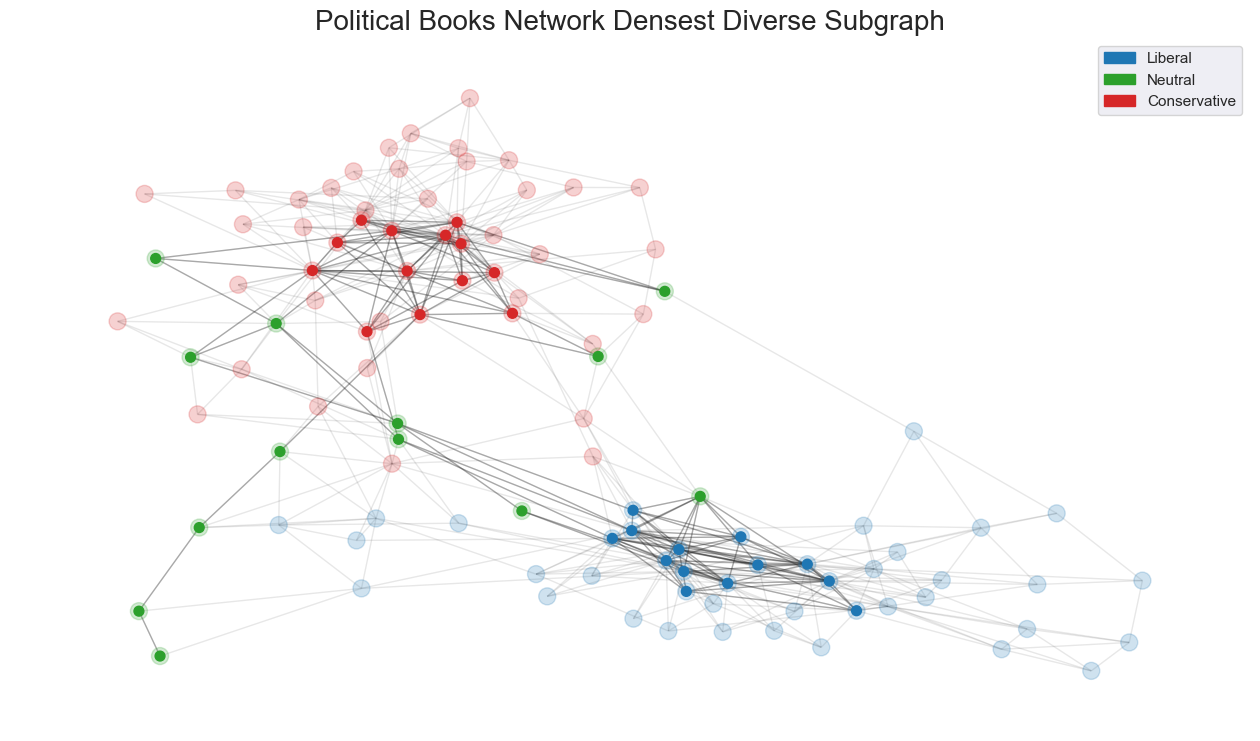

<Figure size 1600x900 with 0 Axes>

In [ ]:
super_greedy_pp_R = super_greedy_pp_lse_DC_SSP(G, S, protected_nodes_all=protected_nodes, lam=100, mu=1.0, alpha=None, num_passes=10)
S= G.subgraph(super_greedy_pp_R[0])

node_colors_G = [color_map[G.nodes[n]['value']] for n in G.nodes()]
node_colors_S = [color_map[S.nodes[n]['value']] for n in S.nodes()]

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(16, 9))
ax = plt.gca()
ax.set_facecolor("#ffffff")   
plt.title("Political Books Network Densest Diverse Subgraph",fontsize = 20)

legend_handles = [
   mpatches.Patch(color='tab:blue', label='Liberal'),
   mpatches.Patch(color='tab:green', label='Neutral'),
   mpatches.Patch(color='tab:red', label='Conservative')
]
plt.legend(handles=legend_handles, loc='upper right')

nx.draw_networkx_nodes(G, pos, node_color=node_colors_G, node_size=150,alpha = 0.21)
nx.draw_networkx_edges(G, pos, alpha=0.1)

nx.draw_networkx_nodes(S, pos, node_color=node_colors_S, node_size=50)

nx.draw_networkx_edges(S, pos, alpha=0.3)

plt.figure(figsize=(16, 9))
print(2*S.number_of_edges()/S.number_of_nodes())

## Belgian Chamber of Representatives visualised

Nodes per party in original graph: {'ECOLO': 13, 'SOC-F': 22, 'SOC-V': 13, 'CDEM-F': 8, 'CDEM-V': 16, 'LDD': 0, 'CDEM-V/VOLKS': 0, 'VOLKS': 26, 'LIB-F': 23, 'LIB-V': 12, 'PP': 0, 'DLB': 0, 'FN': 0, 'IND': 0}


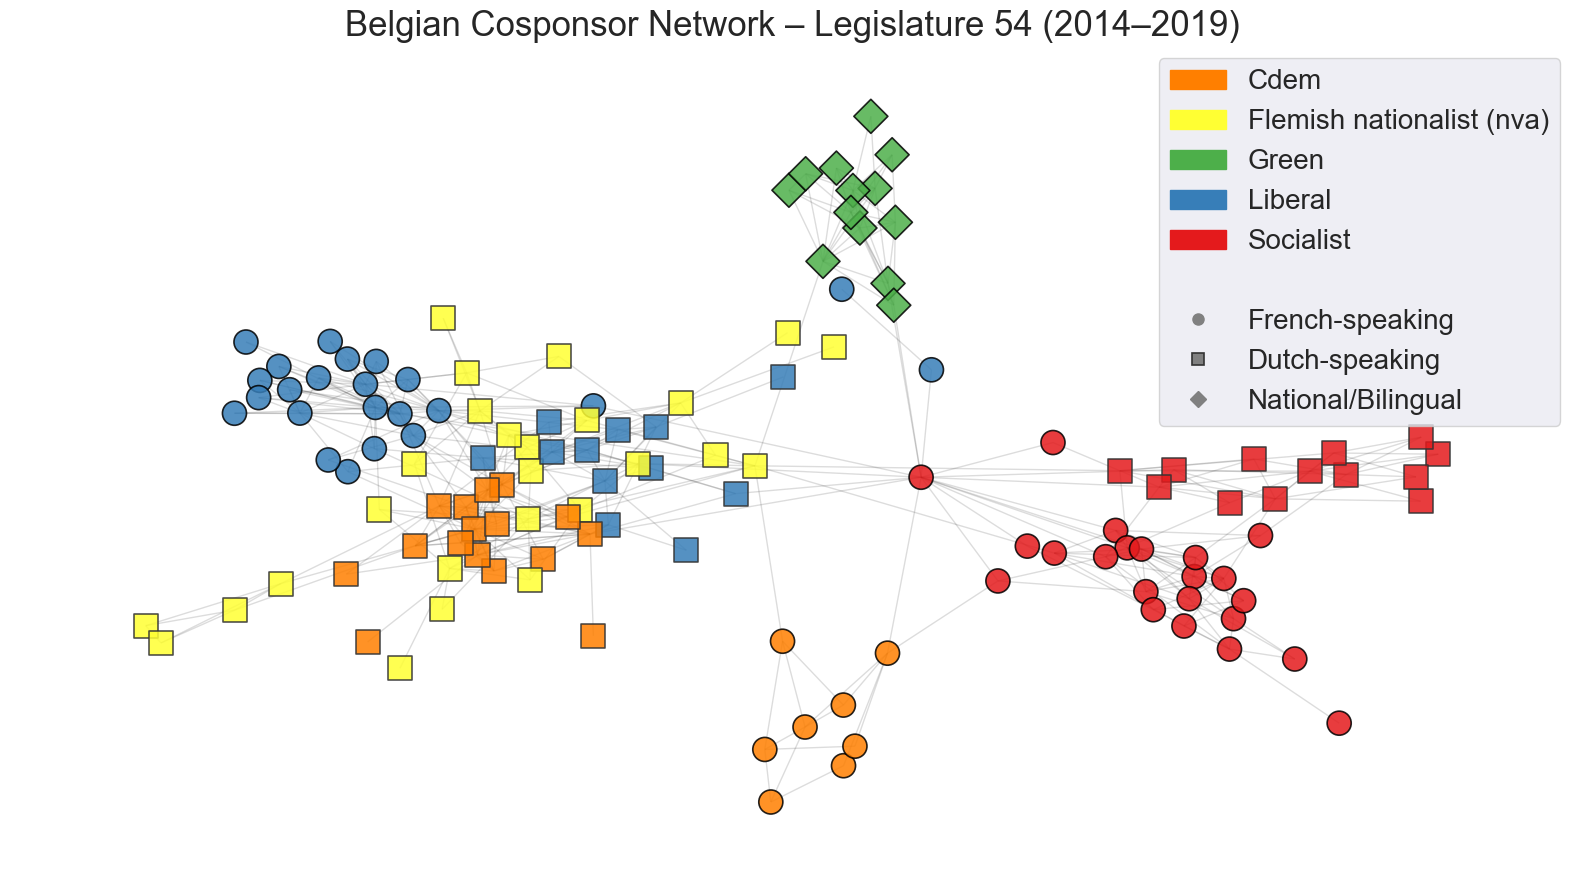

Converged at outer iteration 1


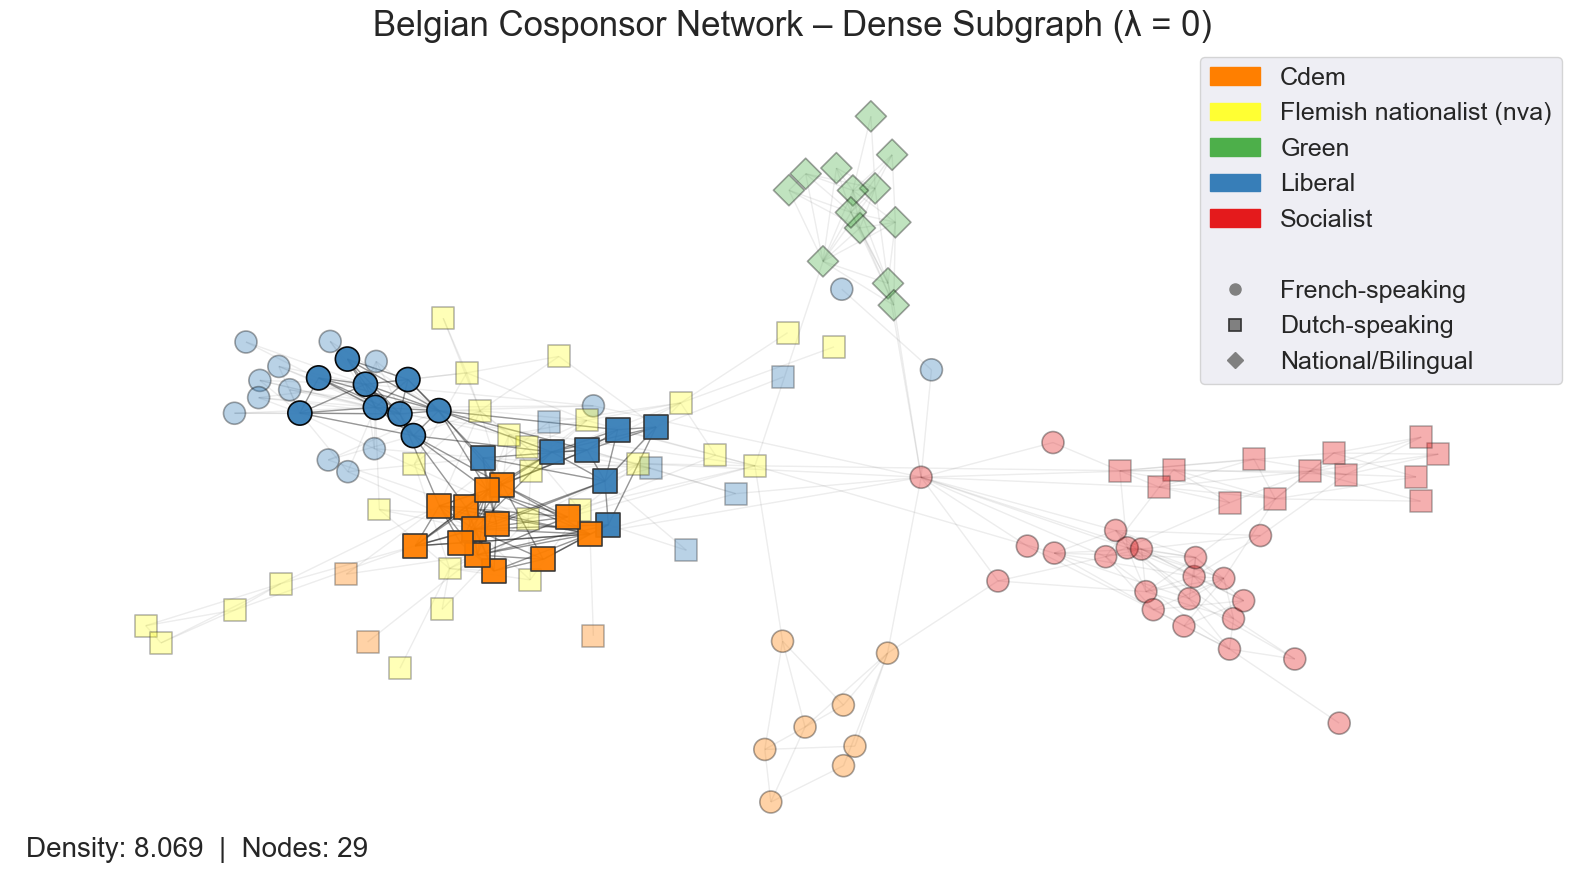

Subgraph: 29 nodes, 117 edges, density 8.0690
Nodes per party: {'CDEM-F': 0, 'CDEM-V': 13, 'ECOLO': 0, 'LIB-F': 9, 'LIB-V': 7, 'SOC-F': 0, 'SOC-V': 0, 'VOLKS': 0}


In [ ]:
G_bel, protected_nodes_bel = init_graph("cosponsorBel")
pos_bel = nx.spring_layout(G_bel, seed=42)
# ── Party family colours (one colour per family, shape distinguishes language) ─
family_colors = {
    "green":       "#4DAF4A",
    "socialist":   "#E41A1C",
    "cdem":        "#FF7F00",
    "liberal":     "#377EB8",
    "flemish nationalist (NVA)": "#FFFF33",
    "farright":    "#984EA3",
    "other":       "#888888",
}
 
party_to_family = {
    "ECOLO":        "green",
    "SOC-F":        "socialist",
    "SOC-V":        "socialist",
    "CDEM-F":       "cdem",
    "CDEM-V":       "cdem",
    "LDD":          "farright",
    "CDEM-V/VOLKS": "cdem",
    "VOLKS":        "flemish nationalist (NVA)",
    "LIB-F":        "liberal",
    "LIB-V":        "liberal",
    "PP":           "farright",
    "DLB":          "other",
    "FN":           "other",
    "IND":          "other",
}
 
french_parties = { "SOC-F", "CDEM-F", "LIB-F", "FN", "PP", "DLB"}
dutch_parties  = {"SOC-V", "CDEM-V", "LIB-V", "LDD", "CDEM-V/VOLKS", "VOLKS"}
 
def bel_family_color(node):
    party = G_bel.nodes[node].get('party', '')
    return family_colors.get(party_to_family.get(party, 'other'), '#CCCCCC')
 
def bel_marker(node):
    party = G_bel.nodes[node].get('party', '')
    if party in french_parties:
        return 'o'
    elif party in dutch_parties:
        return 's'
    return 'D'
 
def bel_edgecolor(node):
    party = G_bel.nodes[node].get('party', '')
    return '#333333' if party in dutch_parties else 'none'
 
def draw_nodes_by_marker(G, pos, nodelist, alpha, node_size, ax):
    """Draw nodes grouped by marker shape."""
    groups = {}
    for n in nodelist:
        m = bel_marker(n)
        groups.setdefault(m, []).append(n)
    for marker, nodes in groups.items():
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes,
            node_color=[bel_family_color(n) for n in nodes],
            edgecolors=[bel_edgecolor(n) for n in nodes],
            linewidths=1.2, node_shape=marker,
            node_size=node_size, alpha=alpha, ax=ax
        )
 
def bel_legend(parties):
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    handles = []
    for fam in sorted({party_to_family.get(p, 'other') for p in parties}):
        handles.append(mpatches.Patch(color=family_colors[fam], label=fam.capitalize()))
    handles.append(mlines.Line2D([], [], color='none', label=''))
    handles.append(mlines.Line2D([], [], marker='o', color='gray', linestyle='None',
                                  markersize=8, label='French-speaking'))
    handles.append(mlines.Line2D([], [], marker='s', color='gray', linestyle='None',
                                  markeredgecolor='#333333', markeredgewidth=1.2,
                                  markersize=8, label='Dutch-speaking'))
    handles.append(mlines.Line2D([], [], marker='D', color='gray', linestyle='None',
                              markersize=8, label='National/Bilingual'))
    return handles
 
 #print each party and its number of nodes in the original graph:
print("Nodes per party in original graph:", {p: sum(1 for n in G_bel.nodes() if G_bel.nodes[n].get('party') == p) for p in party_to_family.keys()})
# ── Full graph ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor("#ffffff")
ax.set_title("Belgian Cosponsor Network – Legislature 54 (2014–2019)", fontsize=25)
for spine in ax.spines.values():
    spine.set_visible(False)
draw_nodes_by_marker(G_bel, pos_bel, list(G_bel.nodes()), alpha=0.85, node_size=300, ax=ax)
nx.draw_networkx_edges(G_bel, pos_bel, alpha=0.15, ax=ax)
present_parties = sorted({G_bel.nodes[n].get('party') for n in G_bel.nodes()} & party_to_family.keys())
ax.legend(handles=bel_legend(present_parties), loc='upper right', fontsize=20, ncol=1)
plt.tight_layout()
plt.savefig("bel_full.svg", format='svg', bbox_inches='tight')
plt.show()
 
 
# ── Subgraph at chosen λ ────────────────────────────────────────────────────
_, protected_nodes_bel = init_graph("cosponsorBel")
lam_bel = 0   # ← adjust lambda here
result_bel = super_greedy_pp_lse_DC_SSP(
    G_bel, G_bel, protected_nodes_bel,
    lam=lam_bel, mu=2.0, alpha=None, num_passes=10, num_outer=20
)
S_bel = G_bel.subgraph(result_bel[0])
 
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor("#ffffff")
ax.set_title(f"Belgian Cosponsor Network – Dense Subgraph (λ = {lam_bel})", fontsize=25)
for spine in ax.spines.values():
    spine.set_visible(False)
# Non-selected: faded
non_selected = [n for n in G_bel.nodes() if n not in S_bel]
draw_nodes_by_marker(G_bel, pos_bel, non_selected, alpha=0.35, node_size=250, ax=ax)
nx.draw_networkx_edges(G_bel, pos_bel, alpha=0.08, ax=ax)
# Selected: full colour
draw_nodes_by_marker(G_bel, pos_bel, list(S_bel.nodes()), alpha=0.95, node_size=300, ax=ax)
nx.draw_networkx_edges(S_bel, pos_bel, alpha=0.4, ax=ax)
 
density_bel =  2*S_bel.number_of_edges() / max(1, S_bel.number_of_nodes())
ax.text(0.01, 0.02, f"Density: {density_bel:.3f}  |  Nodes: {S_bel.number_of_nodes()}",
        transform=ax.transAxes, fontsize=20)
sub_parties = sorted({G_bel.nodes[n].get('party') for n in G_bel.nodes()})
ax.legend(handles=bel_legend(sub_parties), loc='upper right', fontsize=18, ncol=1)
plt.tight_layout()
plt.savefig("bel_subgraph.pdf", format='pdf', bbox_inches='tight')
plt.show()
 
print(f"Subgraph: {S_bel.number_of_nodes()} nodes, {S_bel.number_of_edges()} edges, density {density_bel:.4f}")
print("Nodes per party:", {p: sum(1 for n in S_bel.nodes() if G_bel.nodes[n].get('party') == p)
                           for p in present_parties})
 